In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Social_Network_Ads.csv")

In [3]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [5]:
x=df[['Age','EstimatedSalary']]
y=df['Purchased']

In [6]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.25)

In [7]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
xtrain=sc.fit_transform(xtrain)
xtest=sc.transform(xtest)

In [8]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(xtrain,ytrain)

LogisticRegression()

In [9]:
ytestpred=model.predict(xtest)

In [10]:
from sklearn.metrics import confusion_matrix,accuracy_score, precision_score, recall_score

In [11]:
cm=confusion_matrix(ytest,ytestpred)

In [12]:
print(cm)

[[57  6]
 [12 25]]


In [13]:
tn, fp, fn, tp = cm.ravel()

In [14]:
print('tp:',tp)
print('tn:',tn)
print('fp:',fp)
print('fn:',fn)

tp: 25
tn: 57
fp: 6
fn: 12


In [15]:
accuracy=(tp+tn)/(tp+tn+fp+fn)
print(accuracy)

0.82


In [16]:
error=(fp+fn)/(tp+tn+fp+fn)
print(error)

0.18


In [17]:
precision=(tp)/(tp+fp)
print(precision)

0.8064516129032258


In [18]:
recall=(tp)/(tp+fn)
print(recall)

0.6756756756756757


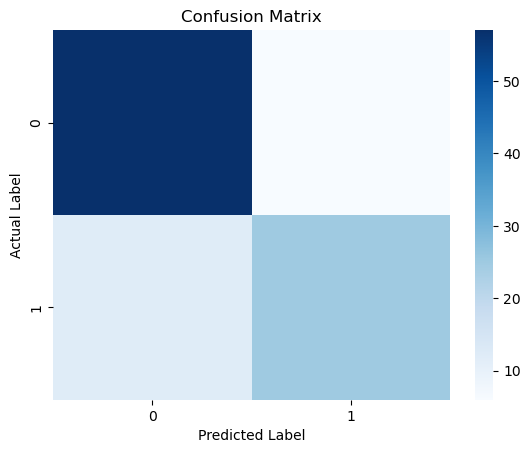

In [19]:
sns.heatmap(cm,cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()